# Plasticity

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib
matplotlib.style.use('seaborn-colorblind')
plt.rc('font', size=12)
plt.rc('legend', fontsize=10)

%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../PalmSim')
sys.path.append('../PalmSim/components')

from PalmField import PalmField

# PalmSim


In [3]:
def go(I):
    # Initiatilize a field at DOP 1986 (coincides with the first weather data)
    p = PalmField(year_of_planting=1986)

    # Attach the weather data
    p.weather.radiation_series = [I]
    
    # Run the model for 360 months.
    df = p.run(duration=360)
    return df

In [4]:
res = []

Is = np.linspace(10,20,10)

for I in Is:

    df = go(I)
    
    vag = df.loc['1994':'2004','assim growth vegetative (t/ha/month)'].mean()
    gag = df.loc['1994':'2004','assim growth generative (t/ha/month)'].mean()

    
    fg = df.loc['1994':'2004','fronds mass growth rate (t/ha/month)'].mean()
    tg = df.loc['1994':'2004','trunk mass growth rate (t/ha/month)'].mean()
    rg = df.loc['1994':'2004','roots mass growth rate (t/ha/month)'].mean()
    
    vg = fg + tg + rg
    y = df.loc['1994':'2004','organs bunch production (t/ha/month)'].mean()
    
    print('.',end='')
    
    res.append([vag,gag,vg,y])

..........

In [5]:
res = np.array(res)

In [6]:
#res

In [7]:
import scipy.optimize as sc

In [8]:
cf = sc.curve_fit

In [9]:
f = lambda x,a,b: a*x + b 

In [10]:
tag = res[:,0] + res[:,1]
vag = res[:,0]
gag = res[:,1]

c = 1000*12/142
vg = c*res[:,2]
y = c*res[:,3]
yha = res[:,3]
tg = vg + y

In [11]:
tgl = np.linspace(50,300,100)

cfv = cf(f,tg,vg)[0]
vgl = tgl*cfv[0] + cfv[1]

cfy = cf(f,tg,y)[0]
yl = tgl*cfy[0] + cfy[1]

In [12]:
cfv

array([5.05393100e-02, 9.46157792e+01])

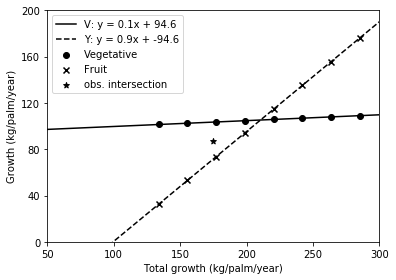

In [13]:
ar = 1.4
size = 4
fig,ax = plt.subplots(figsize=(ar*size,size))

ax.scatter(tg,vg,label='Vegetative',color='black',marker='o')
ax.scatter(tg,y,label='Fruit',color='black',marker='x')

ax.plot(tgl,vgl,color='black',label='V: y = {:}x + {:}'.format(*cfv.round(1)))
ax.plot(tgl,yl,color='black',ls='--',label='Y: y = {:}x + {:}'.format(*cfy.round(1)))

plt.scatter([175.0],[87.5],marker='*',color='black', label='obs. intersection')

ax.set_xlabel('Total growth (kg/palm/year)')
ax.set_ylabel('Growth (kg/palm/year)')
ax.set_ylim(0,200)
ax.set_xlim(50,300)
ax.set_yticks(np.linspace(0,200,6))
ax.legend()

plt.tight_layout()

<img src="images/plasticity_small.png" alt="Plasticity of growth">

In [14]:
def get_cfs(cs):
    a = (cs[1][1] - cs[0][1])/(cs[1][0] - cs[0][0])
    b = cs[1][1]-cs[1][0]*a
    return np.array([a,b]).round(1)

# V
cs = ((120,80),(250,90))
cfs = get_cfs(cs)
print('V obs: {:}x + {:}'.format(*cfs))

# Y
cs = ((120,40),(250,160))
cfs = get_cfs(cs)
print('Y obs: {:}x + {:}'.format(*cfs))

V obs: 0.1x + 70.8
Y obs: 0.9x + -70.8


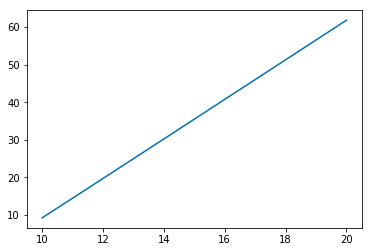

In [15]:
plt.plot(Is,2*12*yha)

In [16]:
# to allow us to work with spreadsheets import the "pandas" library
import pandas as pd

# to allow us to make plots, import a plotting library
import matplotlib.pyplot as plt

# read-in the csv-file
weather_past = pd.read_csv('./input/north_sumatra.csv',index_col='Date')
weather_past.index = pd.to_datetime(weather_past.index)

In [19]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from PalmField import PalmField

weather_data = weather_past

year_of_planting = weather_data.index.year[0]

# 1. Initialize the model
p = PalmField(year_of_planting=year_of_planting)

# 2. Couple the weather data:
p.weather.radiation_series = [weather_data['Solar (MJ/m2)'].mean()]
p.weather.rainfall_series = weather_data['Precip (mm)']

# 3. Run the model
df = p.run(duration=360,)

# copy results for later
df_past = df.copy()

0.5150069045618613


Text(0.5,1,'Pot. vs actual 1967: gap = 0.52')

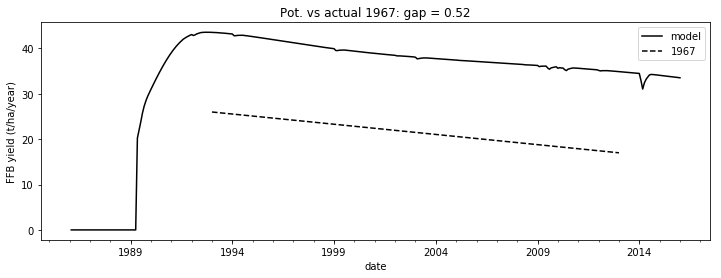

In [54]:
ax = df['organs yield FM yearly (tonne FM/year)'].plot(figsize=(12,4),
                                                       color='black',
                                                       label = 'model')
#df['organs yield FM yearly (tonne FM/year)'].rolling(12,center=True).mean().plot(ax=ax,color='black',ls='--')
ax.set_ylabel('FFB yield (t/ha/year)');

x0 = 6
y0m = df['organs yield FM yearly (tonne FM/year)'].values[x0*12]
x1 = 26
y1m = df['organs yield FM yearly (tonne FM/year)'].values[x1*12]
get_cfs(((x0,y0),(x1,y1)))

((6,26),(25,17))
y0 = 26
y1 = 17

gap = (y1m-y1)/y1m
print(gap)

x00 = df.index.year[0]
d = 12*(x00 - 1969)
ax.plot([d+12*x0,d+12*x1],[y0,y1],linestyle='--',
        label='1967',color='black')
ax.legend()
ax.set_title('Pot. vs actual 1967: gap = {:3.2f}'.format(gap))

<img src="images/yield_MPOB.png" alt="Plasticity of growth">

In [23]:
get_cfs(((6,26),(25,17)))

array([-0.5, 28.8])

array([-0.4, 45.2])